## 4.1

In [50]:
import numpy as np 
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.constants as cst

x = 1E-3 # Ionization fraction

# Calculate the abundances from Table 1.2
abundance_hydrogen = 12 # by definition
abundance_carbon = 12+np.log10(250*0.1/910630) # table1.2 *0.1 for 10% of the abundance
abundance_oxygen = 12+np.log10(550*0.1/910630) # table1.2 *0.1 for 10% of the abundance

print(abundance_carbon)
print(abundance_oxygen)

7.438598054968874
7.7810207357910794


We can now compute the cooling functions for [CII], [OI], and $\mathrm{Ly}\alpha$. The temperature input MUST be in Kelvin, and the output will be in the correct units of $\mathrm{erg\,cm^3\,s^{-1}}$.

In [51]:
def cooling_CII_e(T):
    return 3.1*(x/1E-3)*(T/100)**(-0.5)*np.exp(-91.2/T)*(1E-27)*(10**(abundance_carbon-12))/(2.7E-4) # 1.38 assumes the ratio n_C/n_H to be 2.7E-4
def cooling_CII_H(T):
    return 5.2*(T/100)**(0.13)*np.exp(-91.2/T)*(1E-27)*(10**(abundance_carbon-12))/(2.7E-4) # 1.38 assumes the ratio n_C/n_H to be 2.7E-4
def cooling_OI(T):
    return 4.1*(T/100)**(0.42)*np.exp(-228/T)*(1E-27)*(10**(abundance_oxygen-12))/(6E-4) # 1.38 assumes the ratio n_O/n_H to be 6E-4
def cooling_Lya_e(T):
    return 6E5*(x/1E-3)*(T/1000)**(-0.5)*np.exp(-1.18E5/T)*(1E-27)

We can now use the abundances calculated and compute the total cooling function:

In [55]:
def cooling_func(T):
    CII = (cooling_CII_e(T)+cooling_CII_H(T))
    OI = cooling_OI(T)
    Lya = cooling_Lya_e(T)
    return CII + OI + Lya, {r"[CII]$\lambda 158\mathrm{\mu m}$":CII,
                            r"[OI]$\lambda 63\mathrm{\mu m}$":OI,
                            r"$\mathrm{Ly \alpha}$":Lya}

And finally, we can now plot it like Figure 1.10:

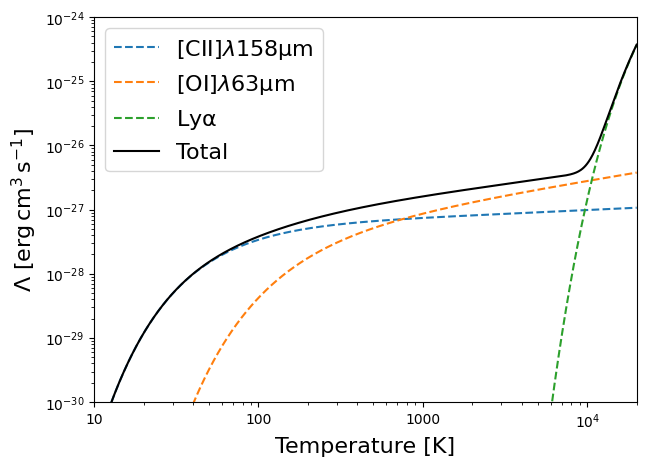

In [57]:
Ts = np.logspace(np.log10(10),np.log10(20000),1000)
cooling_total, cooling_funcs = cooling_func(Ts)
plt.figure(figsize=(7,5))
ax = plt.subplot(111)
for c_func in cooling_funcs.keys():
    ax.plot(Ts,cooling_funcs[c_func],ls="--",marker="None",label=c_func)
ax.plot(Ts,cooling_total,ls="-",marker="None",color="black",label="Total")
ax.set_xlabel(r"Temperature [K]", fontsize=16)
ax.set_ylabel(r"$\Lambda$ [$\mathrm{erg\, cm^{3}\,s^{-1}}$]", fontsize=16)
ax.legend(fontsize=16)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(10,20000)
ax.set_ylim(1E-30,1E-24)
ax.set_xticks([10,100,1000,1E4],labels=["10","100","1000",r"$10^4$"])
plt.show()